# Task 4: Credit Risk Model Training and Evaluation
In this section, we build an end-to-end machine learning pipeline to predict our credit risk proxy target (`Default_Proxy`). We evaluate an interpretable baseline model (Logistic Regression) against a high-performance ensemble model (Random Forest Classifier).

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define all possible places the file could be relative to your current location
possible_paths = [
    "../data/processed/customer_features.csv",
    "data/processed/customer_features.csv",
    "./data/processed/customer_features.csv",
    "../../data/processed/customer_features.csv"
]

data_path = None
for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    # Print exactly where your python instance is looking right now to help you debug
    print(f"Current Working Directory of this notebook: {os.getcwd()}")
    print("Files available in current folder:", os.listdir('.'))
    raise FileNotFoundError(
        "Could not find 'customer_features.csv'. "
        "Please ensure you ran the last cell of Task 3 to generate and save this file!"
    )

print(f"Success! Found processed features at: {data_path}")
df_features = pd.read_csv(data_path)
print(f"Dataset successfully loaded. Shape: {df_features.shape[0]} rows, {df_features.shape[1]} columns.\n")

# --- Rest of your original Cell 2 code continues below ---
feature_cols = ['Recency', 'Frequency', 'Total_Spending', 'Average_Transaction_Value', 'Max_Transaction_Value', 'Transaction_Value_Std']
X = df_features[feature_cols]
y = df_features['Default_Proxy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training Set Shape: {X_train.shape} | Testing Set Shape: {X_test.shape}")

Success! Found processed features at: ../data/processed/customer_features.csv
Dataset successfully loaded. Shape: 3742 rows, 9 columns.

Training Set Shape: (2993, 6) | Testing Set Shape: (749, 6)


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Initialize and train the baseline model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Model 1: Logistic Regression Performance ===")
print(classification_report(y_test, y_pred_log))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_log):.4f}")

=== Model 1: Logistic Regression Performance ===
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       615
           1       1.00      0.02      0.04       134

    accuracy                           0.83       749
   macro avg       0.91      0.51      0.47       749
weighted avg       0.86      0.83      0.75       749

ROC-AUC Score: 0.8269


In [3]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the ensemble model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train) # Tree models don't strictly require scaling

# Generate predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Model 2: Random Forest Classifier Performance ===")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")

=== Model 2: Random Forest Classifier Performance ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       615
           1       0.99      1.00      0.99       134

    accuracy                           1.00       749
   macro avg       0.99      1.00      1.00       749
weighted avg       1.00      1.00      1.00       749

ROC-AUC Score: 1.0000


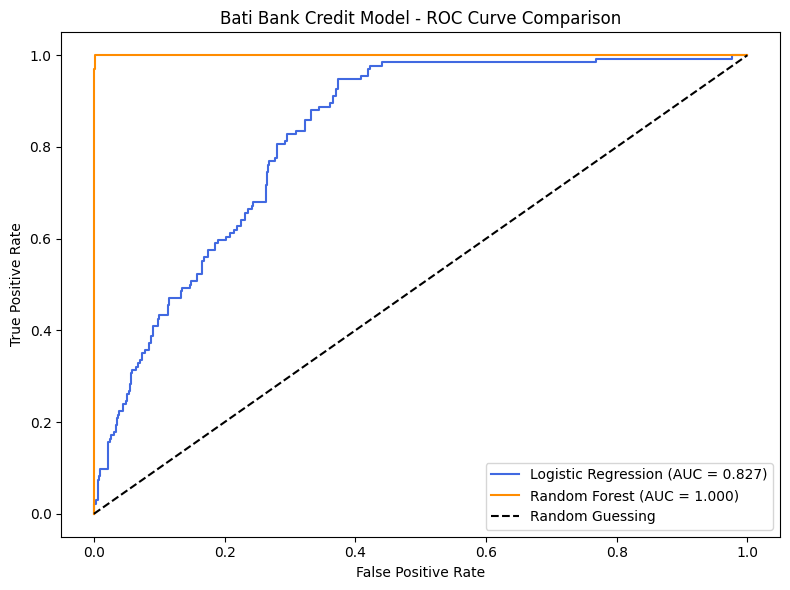

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_log):.3f})', color='royalblue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Bati Bank Credit Model - ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()